# NeuroTrace AI — Data Exploration & Feature Engineering

Ce notebook est la première étape pratique du projet **NeuroTrace AI**.

Objectif : comprendre les datasets disponibles, nettoyer les données, extraire des indicateurs comportementaux et créer un premier score de risque pour les emails du dataset CERT.

Les datasets utilisés :

- **CERT email dataset** : communications internes/externes, utilisateurs, PC, dates, pièces jointes et contenu.
- **Phishing email dataset** : texte/email labellisé pour entraîner un module NLP de détection phishing/manipulation.
- **Psychometric dataset** : traits psychologiques des employés selon le modèle Big Five.
- **User behavior dataset** : comportement applicatif/mobile, utilisé comme dataset secondaire.

## 1. Importation des bibliothèques

On importe les bibliothèques principales :

- `pandas` pour manipuler les datasets.
- `numpy` pour les calculs numériques.
- `matplotlib` et `seaborn` pour la visualisation.
- `os` pour gérer les chemins et fichiers.

In [13]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Définition des chemins des datasets

Les fichiers CSV sont stockés localement dans `datasets/raw/`.

Important : ces datasets sont volumineux, donc ils ne doivent pas être poussés vers GitHub. Le code reste sur GitHub, mais les données restent en local.

In [14]:
RAW_DIR = "datasets/raw"
PROCESSED_DIR = "datasets/processed"
FEATURES_DIR = "datasets/features"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FEATURES_DIR, exist_ok=True)

CERT_PATH = os.path.join(RAW_DIR, "email.csv")
PHISHING_PATH = os.path.join(RAW_DIR, "phishing_email.csv")
PSY_PATH = os.path.join(RAW_DIR, "psychometric.csv")
BEHAVIOR_PATH = os.path.join(RAW_DIR, "userbehaviour.csv")

print(os.listdir(RAW_DIR))

['.gitkeep', 'email.csv', 'phishing_email.csv', 'psychometric.csv', 'userbehaviour.csv']


## 3. Chargement des datasets

On charge les quatre datasets principaux.

Le dataset CERT est très grand, donc il peut prendre un peu de temps à charger.

In [15]:
cert_df = pd.read_csv(CERT_PATH)
phishing_df = pd.read_csv(PHISHING_PATH)
psy_df = pd.read_csv(PSY_PATH)
behavior_df = pd.read_csv(BEHAVIOR_PATH)

print("CERT:", cert_df.shape)
print("Phishing:", phishing_df.shape)
print("Psychometric:", psy_df.shape)
print("Behavior:", behavior_df.shape)

CERT: (2629979, 11)
Phishing: (82486, 2)
Psychometric: (1000, 7)
Behavior: (999, 8)


## 4. Aperçu général des données CERT

On affiche les premières lignes pour comprendre les colonnes disponibles.

Dans CERT, chaque ligne représente un email envoyé dans l'entreprise.

In [16]:
cert_df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockheedmartin.com,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful destroyed who larger speeds plains part paul hold like followed over de...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former further victories casualties one 18 douglas well sea until difficulty...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition exist powered circumhorizontal contain one seasonally off glenn make add...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered probably especially for 37 humidity take conditions has gas bearing wo...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;Jane_Mcdonald@juno.com,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unusually crew have amidst if succession fresh recorded continued and and...


## 5. Structure et types des colonnes

Cette étape permet de vérifier :

- le nombre de lignes ;
- les colonnes ;
- les types de données ;
- la mémoire utilisée.

In [17]:
cert_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2629979 entries, 0 to 2629978
Data columns (total 11 columns):
 #   Column       Dtype
---  ------       -----
 0   id           str  
 1   date         str  
 2   user         str  
 3   pc           str  
 4   to           str  
 5   cc           str  
 6   bcc          str  
 7   from         str  
 8   size         int64
 9   attachments  int64
 10  content      str  
dtypes: int64(2), str(9)
memory usage: 220.7 MB


## 6. Valeurs manquantes

On vérifie les valeurs nulles.

Dans les emails, il est normal que les colonnes `cc` et `bcc` contiennent beaucoup de valeurs manquantes, car tous les emails n'ont pas forcément de destinataires en copie ou copie cachée.

In [18]:
missing_values = cert_df.isnull().sum().sort_values(ascending=False)
missing_values

bcc            2212977
cc             1617054
id                   0
user                 0
date                 0
to                   0
pc                   0
from                 0
size                 0
attachments          0
content              0
dtype: int64

## 7. Conversion de la date et création des variables temporelles

La colonne `date` est convertie en format datetime.

Ensuite, on extrait :

- `hour` : l'heure d'envoi ;
- `day` : le jour de la semaine ;
- `month` : le mois ;
- `date_only` : la date sans heure.

Ces variables sont importantes pour détecter les comportements anormaux, par exemple les emails envoyés la nuit.

In [19]:
cert_df["date"] = pd.to_datetime(cert_df["date"], errors="coerce")

cert_df["hour"] = cert_df["date"].dt.hour
cert_df["day"] = cert_df["date"].dt.day_name()
cert_df["month"] = cert_df["date"].dt.to_period("M").astype(str)
cert_df["date_only"] = cert_df["date"].dt.date

cert_df[["date", "hour", "day", "month"]].head()

,date,hour,day,month
0,2010-01-02 07:11:45,7,Saturday,2010-01
1,2010-01-02 07:12:16,7,Saturday,2010-01
2,2010-01-02 07:13:00,7,Saturday,2010-01
3,2010-01-02 07:13:17,7,Saturday,2010-01
4,2010-01-02 07:13:28,7,Saturday,2010-01


## 8. Analyse des heures d'activité

On observe la distribution des emails par heure.

Cette analyse permet de déterminer les horaires normaux de travail. Dans ce dataset, la majorité des emails est envoyée entre 8h et 17h.

In [20]:
hour_distribution = cert_df["hour"].value_counts().sort_index()
hour_distribution

hour
6        747
7      87128
8     275242
9     280340
10    257407
11    243452
12    243695
13    263172
14    271915
15    277974
16    217994
17    131508
18     51708
19     16784
20      8361
21      2409
22        67
23        76
Name: count, dtype: int64

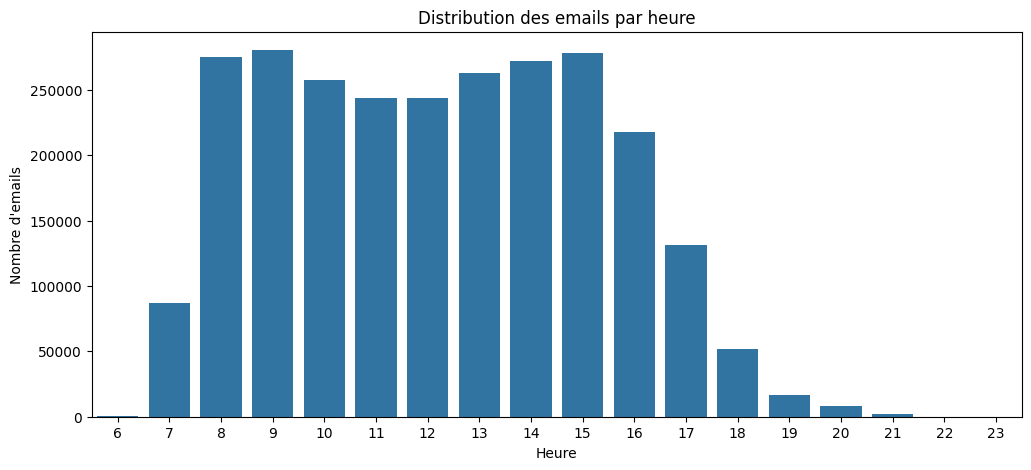

In [21]:
plt.figure(figsize=(12, 5))
sns.barplot(x=hour_distribution.index, y=hour_distribution.values)
plt.title("Distribution des emails par heure")
plt.xlabel("Heure")
plt.ylabel("Nombre d'emails")
plt.show()

## 9. Création de la variable `night_activity`

On considère qu'un email envoyé entre 21h et 6h est une activité nocturne.

Ce n'est pas automatiquement dangereux, mais cela devient un signal de risque si un utilisateur a beaucoup d'activités nocturnes ou si ces activités sont combinées avec des pièces jointes, des emails externes ou des fichiers sensibles.

In [22]:
cert_df["night_activity"] = cert_df["hour"].apply(
    lambda x: 1 if x >= 21 or x <= 6 else 0
)

cert_df["night_activity"].value_counts()

night_activity
0    2626680
1       3299
Name: count, dtype: int64

## 10. Top utilisateurs avec activité nocturne

On cherche les utilisateurs qui envoient le plus d'emails pendant la nuit.

Ces utilisateurs seront des candidats potentiels pour l'analyse comportementale.

In [23]:
night_users = (
    cert_df.groupby("user")["night_activity"]
    .sum()
    .sort_values(ascending=False)
)

night_users.head(10)

user
GTD0116    237
HRL0540    163
KBP0008    151
TLK0993    149
LAF0991    147
KCO0122    141
HOB0994    140
DLM0051    116
HAV0121     90
LRR0148     87
Name: night_activity, dtype: int64

## 11. Détection des communications externes

Dans le dataset CERT, le domaine interne de l'entreprise est souvent `@dtaa.com`.

Si un email est envoyé vers un domaine différent, on le considère comme une communication externe.

Cette variable est très importante pour détecter les risques d'exfiltration de données.

In [24]:
INTERNAL_DOMAIN = "@dtaa.com"

def contains_external_email(value, internal_domain=INTERNAL_DOMAIN):
    """
    Retourne 1 si la chaîne contient au moins un email externe.
    Retourne 0 si tous les emails détectés semblent internes.
    """
    if pd.isna(value):
        return 0
    text = str(value).lower()
    emails = re.findall(r"[\w\.-]+@[\w\.-]+", text)
    if len(emails) == 0:
        return 0
    return int(any(internal_domain not in email for email in emails))

cert_df["external_to"] = cert_df["to"].apply(contains_external_email)
cert_df["external_cc"] = cert_df["cc"].apply(contains_external_email)
cert_df["external_bcc"] = cert_df["bcc"].apply(contains_external_email)
cert_df["external_from"] = cert_df["from"].apply(contains_external_email)

cert_df[["to", "cc", "bcc", "from", "external_to", "external_cc", "external_bcc", "external_from"]].head()

,to,cc,bcc,from,external_to,external_cc,external_bcc,external_from
0,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockheedmartin.com,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,1,0,0,0
1,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,1,0,0,1
2,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,1,0,0,1
3,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,1,0,0,1
4,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;Jane_Mcdonald@juno.com,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,1,0,1,1


## 12. Analyse des emails externes

On mesure combien d'emails impliquent des communications externes.

In [25]:
external_summary = cert_df[["external_to", "external_cc", "external_bcc", "external_from"]].sum().sort_values(ascending=False)
external_summary

external_to      1191988
external_from     989956
external_cc       465561
external_bcc      138812
dtype: int64

## 13. Détection des emails volumineux

Un email très volumineux peut indiquer un transfert important de données.

On marque comme `large_email` les emails dont la taille est supérieure au 95e percentile.

In [26]:
size_threshold = cert_df["size"].quantile(0.95)
print("Large email threshold:", size_threshold)

cert_df["large_email"] = cert_df["size"].apply(lambda x: 1 if x > size_threshold else 0)
cert_df[["size", "large_email"]].head()

Large email threshold: 48529.0


,size,large_email
0,25830,0
1,29942,0
2,28780,0
3,21907,0
4,17319,0


## 14. Risque lié aux pièces jointes

Un email avec pièce jointe n'est pas forcément dangereux.

Mais un email volumineux avec pièce jointe, surtout s'il est envoyé vers l'extérieur, peut être un signal de risque.

In [27]:
cert_df["attachment_risk"] = cert_df.apply(
    lambda row: 1 if row["attachments"] > 0 and row["large_email"] == 1 else 0,
    axis=1
)

cert_df["attachment_risk"].value_counts()

attachment_risk
0    2601753
1      28226
Name: count, dtype: int64

## 15. Premier score de risque email

On crée un score simple basé sur plusieurs signaux :

- activité nocturne ;
- communication externe ;
- email externe en cc/bcc ;
- expéditeur externe ;
- email volumineux avec pièce jointe.

Ce score n'est pas encore un modèle IA complet. C'est une première règle intelligente pour construire une base de risque.

In [28]:
cert_df["email_risk_score"] = (
    cert_df["night_activity"] * 30 +
    cert_df["external_to"] * 20 +
    cert_df["external_cc"] * 10 +
    cert_df["external_bcc"] * 15 +
    cert_df["external_from"] * 10 +
    cert_df["attachment_risk"] * 30
)

cert_df[["user", "date", "to", "from", "size", "attachments", "email_risk_score"]].head()

,user,date,to,from,size,attachments,email_risk_score
0,LAP0338,2010-01-02 07:11:45,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockheedmartin.com,Lynn.Adena.Pratt@dtaa.com,25830,0,20
1,MOH0273,2010-01-02 07:12:16,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,29942,0,30
2,LAP0338,2010-01-02 07:13:00,Penelope_Colon@netzero.com,Lynn_A_Pratt@earthlink.net,28780,0,30
3,LAP0338,2010-01-02 07:13:17,Judith_Hayden@comcast.net,Lynn_A_Pratt@earthlink.net,21907,0,30
4,MOH0273,2010-01-02 07:13:28,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;Jane_Mcdonald@juno.com,MOH68@optonline.net,17319,0,45


## 16. Statistiques du score de risque

On analyse la distribution du score pour comprendre les emails normaux et les emails suspects.

In [29]:
cert_df["email_risk_score"].describe()

count    2.629979e+06
mean     1.575026e+01
std      1.776872e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+01
max      1.150000e+02
Name: email_risk_score, dtype: float64

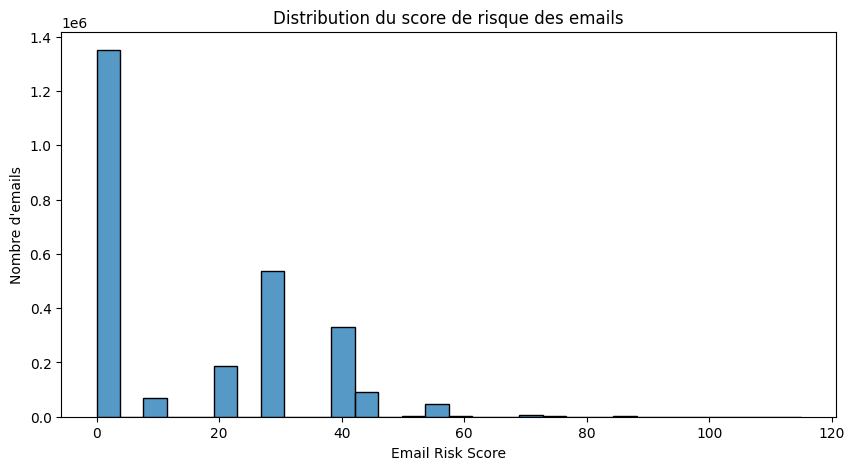

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(cert_df["email_risk_score"], bins=30)
plt.title("Distribution du score de risque des emails")
plt.xlabel("Email Risk Score")
plt.ylabel("Nombre d'emails")
plt.show()

## 17. Top emails suspects

On affiche les emails qui ont le score de risque le plus élevé.

Ces emails seront utilisés plus tard dans le module d'investigation.

In [31]:
top_suspicious_emails = cert_df.sort_values("email_risk_score", ascending=False).head(20)
top_suspicious_emails[[
    "id", "date", "user", "pc", "to", "from", "size", "attachments", 
    "night_activity", "external_to", "external_cc", "external_bcc", "external_from", 
    "attachment_risk", "email_risk_score"
]]

,id,date,user,pc,to,from,size,attachments,night_activity,external_to,external_cc,external_bcc,external_from,attachment_risk,email_risk_score
1039632,{H9Z7-M7GF51OI-8855NEBE},2010-07-07 21:29:08,BVC0790,PC-0008,BRB6877@gmail.com,Blythe_Cooke@charter.net,53704,9,1,1,1,1,1,1,115
2602291,{I7F2-V4JS31AK-0167NXUU},2011-05-10 21:13:37,HRL0540,PC-1117,GNS462@bellsouth.net,Hedwig-Livingston@verizon.net,50497,1,1,1,1,1,1,1,115
1742940,{R8X8-C5JD06ES-0967PEDI},2010-11-16 06:55:52,KBP0008,PC-3851,Stokes-Edward@msn.com;TVS8228@aol.com,Kirby.B.Pollard@juno.com,58778,1,1,1,1,1,1,1,115
1195969,{K5D4-P9QR57KF-3251EGFK},2010-08-05 06:54:25,NGF0157,PC-6056,Eve_Mckenzie@comcast.net;Libby_Richard@msn.com;Alfreda.S.Savage@yahoo.com,French-Nissim@hotmail.com,48867,2,1,1,1,1,1,1,115
1334809,{R0P9-D5VT26LR-7153WALS},2010-08-31 06:59:12,NGF0157,PC-6056,Libby_Richard@msn.com;Sasha_Huffman@netzero.com;Eve_Mckenzie@comcast.net,French-Nissim@hotmail.com,59419,1,1,1,0,1,1,1,105
1047297,{E3A1-V7IX56RV-2378IULE},2010-07-08 21:04:20,COF0120,PC-2559,Brianna.R.Mcintyre@cox.net;Burke-Harrison@gmail.com,Clio_O_Faulkner@cox.net,58105,2,1,1,1,0,1,1,100
1480263,{Q2P6-C7TK07ZK-1764FCLX},2010-09-28 06:58:05,EIM0156,PC-1874,Libby_Richard@msn.com;Sasha_Huffman@netzero.com,Eve_Mckenzie@comcast.net,48614,1,1,1,1,0,1,1,100
2202076,{U1Z4-M3JU62XY-0020LYSF},2011-02-18 06:57:06,AJD0074,PC-3135,ADC8783@charter.net,Alden_Day@cox.net,75364,2,1,1,1,0,1,1,100
1457264,{U9Y6-D5OK63ZQ-6356QYKZ},2010-09-22 21:06:59,HRL0540,PC-1117,TLH9998@optonline.net;Kay-Skinner@yahoo.com;Vargas.James@earthlink.net,Hedwig-Livingston@verizon.net,49171,1,1,1,1,0,1,1,100
1608148,{Y6N8-G3MW92EZ-7567EQVX},2010-10-20 21:20:09,BRM0995,PC-0768,Tallulah.L.Kirby@aol.com;Kermit_Oliver@hotmail.com,Brianna.R.Mcintyre@cox.net,54411,2,1,1,1,0,1,1,100


## 18. Création du profil comportemental utilisateur

On agrège les emails par utilisateur afin de créer un profil comportemental.

Pour chaque utilisateur, on calcule :

- nombre total d'emails ;
- nombre d'emails nocturnes ;
- taux d'activité nocturne ;
- nombre d'emails externes ;
- nombre d'emails avec pièces jointes ;
- taille moyenne des emails ;
- score de risque moyen ;
- score de risque maximal.

In [32]:
user_profile = cert_df.groupby("user").agg(
    total_emails=("id", "count"),
    night_emails=("night_activity", "sum"),
    external_to_count=("external_to", "sum"),
    external_cc_count=("external_cc", "sum"),
    external_bcc_count=("external_bcc", "sum"),
    external_from_count=("external_from", "sum"),
    attachment_count=("attachments", "sum"),
    attachment_risk_count=("attachment_risk", "sum"),
    avg_email_size=("size", "mean"),
    max_email_size=("size", "max"),
    avg_email_risk=("email_risk_score", "mean"),
    max_email_risk=("email_risk_score", "max")
).reset_index()

user_profile["night_activity_rate"] = user_profile["night_emails"] / user_profile["total_emails"]
user_profile["external_to_rate"] = user_profile["external_to_count"] / user_profile["total_emails"]
user_profile["attachment_risk_rate"] = user_profile["attachment_risk_count"] / user_profile["total_emails"]

user_profile.head()

,user,total_emails,night_emails,external_to_count,external_cc_count,external_bcc_count,external_from_count,attachment_count,attachment_risk_count,avg_email_size,max_email_size,avg_email_risk,max_email_risk,night_activity_rate,external_to_rate,attachment_risk_rate
0,AAE0190,4711,0,2097,607,0,1770,1780,38,30020.394184,95612,14.190193,70,0.000000,0.445128,0.008066
1,AAF0535,480,0,175,101,60,121,364,9,30397.402083,87253,14.354167,85,0.000000,0.364583,0.018750
2,AAF0791,3012,0,1777,496,0,1608,0,0,29958.497676,83088,18.784861,40,0.000000,0.589973,0.000000
3,AAL0706,336,0,177,53,0,149,145,4,29828.181548,79636,16.904762,60,0.000000,0.526786,0.011905
4,AAM0658,659,26,315,86,0,254,613,15,29895.532625,80991,16.585736,70,0.039454,0.477997,0.022762


## 19. Score de risque utilisateur

On calcule un premier score de risque global pour chaque utilisateur.

Ce score combine :

- le score moyen des emails ;
- le taux d'activité nocturne ;
- le taux de communication externe ;
- le taux de risque lié aux pièces jointes.

Ce score sera amélioré plus tard avec le Machine Learning, le NLP et le graphe relationnel.

In [33]:
user_profile["user_risk_score"] = (
    user_profile["avg_email_risk"] * 0.40 +
    user_profile["night_activity_rate"] * 100 * 0.25 +
    user_profile["external_to_rate"] * 100 * 0.20 +
    user_profile["attachment_risk_rate"] * 100 * 0.15
)

user_profile.sort_values("user_risk_score", ascending=False).head(20)

,user,total_emails,night_emails,external_to_count,external_cc_count,external_bcc_count,external_from_count,attachment_count,attachment_risk_count,avg_email_size,max_email_size,avg_email_risk,max_email_risk,night_activity_rate,external_to_rate,attachment_risk_rate,user_risk_score
300,EIS0041,3287,0,2110,1410,795,1951,1999,48,29696.331305,82753,27.129601,85,0.000000,0.641923,0.014603,23.909340
24,AHG0634,463,20,274,195,108,253,251,7,30719.274298,74989,26.760259,85,0.043197,0.591793,0.015119,23.846652
156,CAS0507,1003,0,611,419,213,560,529,15,30450.495513,77885,25.578265,85,0.000000,0.609172,0.014955,22.639083
513,JMK0099,2989,0,1709,1297,1114,1518,1815,61,30005.846771,96047,27.055872,85,0.000000,0.571763,0.020408,22.563734
527,JSA0775,991,0,595,406,216,536,760,21,29922.817356,76556,25.418769,85,0.000000,0.600404,0.021191,22.493441
545,KCO0122,3033,141,1696,1156,568,1499,1872,40,29939.500824,83209,24.536762,85,0.046489,0.559182,0.013188,22.358391
391,HCS0003,9097,0,5436,3594,2062,4917,7372,173,30208.924810,94350,25.277564,85,0.000000,0.597560,0.019017,22.347477
867,SJF0094,3360,0,1920,1412,1206,1707,2141,46,29966.407738,127741,26.505952,85,0.000000,0.571429,0.013690,22.236310
375,GTD0219,1262,0,749,504,275,685,705,15,30380.007132,79638,24.916799,85,0.000000,0.593502,0.011886,22.015055
668,MLM0950,404,0,235,156,93,207,297,10,30430.373762,83516,24.814356,85,0.000000,0.581683,0.024752,21.930693


## 20. Sauvegarde du profil utilisateur

On sauvegarde le profil comportemental dans `datasets/features/`.

Ce fichier sera utilisé plus tard par :

- le modèle d'anomaly detection ;
- le dashboard ;
- le moteur d'investigation.

In [34]:
USER_PROFILE_PATH = os.path.join(FEATURES_DIR, "user_behavior_profile.csv")
user_profile.to_csv(USER_PROFILE_PATH, index=False)

print("Saved:", USER_PROFILE_PATH)
print("Shape:", user_profile.shape)

Saved: datasets/features\user_behavior_profile.csv
Shape: (1000, 17)


## 21. Exploration du dataset psychométrique

Ce dataset contient les traits de personnalité des employés selon le modèle Big Five :

- O : Openness ;
- C : Conscientiousness ;
- E : Extraversion ;
- A : Agreeableness ;
- N : Neuroticism.

Il sera utilisé pour ajouter une dimension psychologique au profil utilisateur.

In [35]:
psy_df.head()

,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


In [36]:
psy_df.describe()

,O,C,E,A,N
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,33.173000,30.653000,29.19700,28.821000,29.608000
std,10.642007,11.291505,10.95647,11.170844,4.938494
min,10.000000,10.000000,10.00000,10.000000,14.000000
25%,23.000000,20.000000,19.00000,19.000000,26.000000
50%,36.000000,33.000000,28.00000,27.000000,29.000000
75%,42.000000,40.000000,39.00000,39.000000,33.000000
max,50.000000,50.000000,50.00000,50.000000,49.000000


## 22. Fusion du profil comportemental avec les données psychométriques

Si les deux datasets partagent la colonne `user_id` ou une colonne compatible, on pourra les fusionner directement.

Dans CERT, la colonne utilisateur s'appelle `user`, tandis que dans psychometric elle peut s'appeler `user_id`. On vérifie d'abord les noms des colonnes.

In [37]:
print("CERT user profile columns:", user_profile.columns.tolist())
print("Psychometric columns:", psy_df.columns.tolist())

CERT user profile columns: ['user', 'total_emails', 'night_emails', 'external_to_count', 'external_cc_count', 'external_bcc_count', 'external_from_count', 'attachment_count', 'attachment_risk_count', 'avg_email_size', 'max_email_size', 'avg_email_risk', 'max_email_risk', 'night_activity_rate', 'external_to_rate', 'attachment_risk_rate', 'user_risk_score']
Psychometric columns: ['employee_name', 'user_id', 'O', 'C', 'E', 'A', 'N']


## 23. Préparation du dataset phishing

Le dataset phishing servira au module NLP.

Objectif : entraîner un modèle capable de détecter si un message/email est suspect ou non.

On commence par afficher les colonnes et quelques lignes.

In [38]:
print(phishing_df.shape)
print(phishing_df.columns.tolist())
phishing_df.head()

(82486, 2)
['text_combined', 'label']


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen p...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april 1 2001 teco tap 35 ...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


## 24. Nettoyage automatique du dataset phishing

Selon le fichier téléchargé, les colonnes peuvent avoir des noms différents.

Le code suivant essaie d'identifier automatiquement :

- la colonne contenant le texte ;
- la colonne contenant le label.

In [39]:
def find_text_and_label_columns(df):
    cols = [c.lower() for c in df.columns]
    text_candidates = ["body", "text", "content", "message", "email", "subject"]
    label_candidates = ["label", "class", "target", "status", "type"]

    text_col = None
    label_col = None

    for candidate in text_candidates:
        for col in df.columns:
            if candidate == col.lower() or candidate in col.lower():
                text_col = col
                break
        if text_col:
            break

    for candidate in label_candidates:
        for col in df.columns:
            if candidate == col.lower() or candidate in col.lower():
                label_col = col
                break
        if label_col:
            break

    return text_col, label_col

text_col, label_col = find_text_and_label_columns(phishing_df)
print("Detected text column:", text_col)
print("Detected label column:", label_col)

if text_col and label_col:
    phishing_clean = phishing_df[[text_col, label_col]].copy()
    phishing_clean.columns = ["text", "label"]
    phishing_clean = phishing_clean.dropna()
    print(phishing_clean.shape)
    display(phishing_clean.head())
else:
    print("Could not detect text/label columns automatically. Please rename columns manually.")

Detected text column: text_combined
Detected label column: label
(82486, 2)


,text,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen p...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april 1 2001 teco tap 35 ...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


## 25. Sauvegarde du dataset phishing nettoyé

Si le nettoyage automatique a fonctionné, on sauvegarde le dataset prêt pour l'entraînement NLP.

In [40]:
if "phishing_clean" in globals():
    PHISHING_CLEAN_PATH = os.path.join(PROCESSED_DIR, "phishing_clean.csv")
    phishing_clean.to_csv(PHISHING_CLEAN_PATH, index=False)
    print("Saved:", PHISHING_CLEAN_PATH)

Saved: datasets/processed\phishing_clean.csv


## 26. Résumé de la phase Data Exploration

À ce stade, nous avons :

1. chargé les datasets ;
2. analysé la structure du dataset CERT ;
3. extrait les heures, jours et mois ;
4. détecté les activités nocturnes ;
5. détecté les communications externes ;
6. créé un premier score de risque email ;
7. construit un profil comportemental utilisateur ;
8. préparé le dataset phishing pour le module NLP.

Prochaine étape : créer un modèle Machine Learning d'anomaly detection à partir de `user_behavior_profile.csv`.